### Tarea2 - Juan de Dios Murillo Morera


In [1]:
from bs4 import BeautifulSoup
import requests, os, string
import pandas as pd
import numpy as np 
import re

### Ejercicio1

In [2]:
url = requests.get('https://www.20minutos.es/deportes/noticia/4882726/0/agenda-deportiva-814-noviembre/').text
pagina = BeautifulSoup(url, 'html.parser')

In [3]:
#a) Obtenga todo texto que tenga relación con los encuentros deportivos de la semana.

etqEj1 = pagina.find_all("p")
print(etqEj1[0].text.strip())

etqEj2 = pagina.find_all("h2")
for i in range(7):
   print(etqEj2[i].text.strip())

etqEj3 = pagina.find_all("p")
for i in range(1,39):
   print(etqEj3[i].text.strip())


El fútbol de selecciones vuelve a acaparar las miradas en la semana deportiva con los partidos de España en los que se juega a vida o muerte su pase directo al Mundial de Catar. En el mundo del motor, Raúl Fernández en Moto2 es la única opción española que queda para ganar el título tras el conseguido por Pedro Acosta, y la F1 vivirá un nuevo enfrentamiento entre Hamilton y Verstappen en la lucha por el campeonato.
Lunes 8 de noviembre
Martes 9 de noviembre
Miércoles 10 de noviembre
Jueves 11 de noviembre
Viernes 12 de noviembre
Sábado 13 de noviembre
Domingo 14 de noviembre
21:00 - Segunda División: Tenerfe vs. Girona
1:00 - NBA: Chicago Bulls vs. Brooklyn Nets
14:10 - Next Gen ATP Finals: Round Robin
20:30 - Champions League Baloncesto: Baxi Manresa vs. Pinar Karsiyaka
21:00 - Women's Champions League: PSG vs. Real Madrid
1:30 - NBA: Milwaukee Bucks vs. Philadelphia 76ers
14:10 - Next Gen ATP Finals: Round Robin
18:45 -  Women's Champions League: FC Barcelona vs. Hoffenheim
20:30 - C

In [4]:
#b) Mediante expresiones regulares obtenga cada uno de los encuentros en una lista.
lista = []
for i in range(1,39):
   lista.append(re.split("\n", etqEj3[i].text.strip().replace(u"\xa0", u" ")))
lista

[['21:00 - Segunda División: Tenerfe vs. Girona'],
 ['1:00 - NBA: Chicago Bulls vs. Brooklyn Nets'],
 ['14:10 - Next Gen ATP Finals: Round Robin'],
 ['20:30 - Champions League Baloncesto: Baxi Manresa vs. Pinar Karsiyaka'],
 ["21:00 - Women's Champions League: PSG vs. Real Madrid"],
 ['1:30 - NBA: Milwaukee Bucks vs. Philadelphia 76ers'],
 ['14:10 - Next Gen ATP Finals: Round Robin'],
 ["18:45 -  Women's Champions League: FC Barcelona vs. Hoffenheim"],
 ['20:30 - Champions League Baloncesto: Lenovo Tenerife vs. BC Promptey'],
 ['21:00 - WTA Finals: Round Robin'],
 ['4:00 - NBA: Los Angeles Lakers vs. Miami Heat'],
 ['20:45 - Clasificación Mundial Catar 2022: Grecia vs. España'],
 ['21:00 - Euroliga: Barça vs. Bitci Baskonia'],
 ['1:30 - Clasificación Mundial Catar 2022: Brasil vs. Colombia'],
 ['20:00 - GP Brasil F1: Clasificación'],
 ['20:45 - Euroliga: Real Madrid vs. Zalgiris Kaunas'],
 ['20:45 - Clasificación Mundial Catar 2022: Italia vs. Suiza'],
 ['21:00 - Segunda División: Spor

In [5]:
#c) Mediante expresiones regulares obtenga los encuentros que involucran exactamente 2 equipos.
cadenas = []
regex = r'vs.'
for i in range(1,39):
   cadena = etqEj3[i].text.strip()
   matches = re.findall(regex, cadena)
   if matches:
     cadenas.append(cadena.replace(u"\xa0", u" "))  
cadenas        

['21:00 - Segunda División: Tenerfe vs. Girona',
 '1:00 - NBA: Chicago Bulls vs. Brooklyn Nets',
 '20:30 - Champions League Baloncesto: Baxi Manresa vs. Pinar Karsiyaka',
 "21:00 - Women's Champions League: PSG vs. Real Madrid",
 '1:30 - NBA: Milwaukee Bucks vs. Philadelphia 76ers',
 "18:45 -  Women's Champions League: FC Barcelona vs. Hoffenheim",
 '20:30 - Champions League Baloncesto: Lenovo Tenerife vs. BC Promptey',
 '4:00 - NBA: Los Angeles Lakers vs. Miami Heat',
 '20:45 - Clasificación Mundial Catar 2022: Grecia vs. España',
 '21:00 - Euroliga: Barça vs. Bitci Baskonia',
 '1:30 - Clasificación Mundial Catar 2022: Brasil vs. Colombia',
 '20:45 - Euroliga: Real Madrid vs. Zalgiris Kaunas',
 '20:45 - Clasificación Mundial Catar 2022: Italia vs. Suiza',
 '21:00 - Segunda División: Sporting vs. Real Sociedad B',
 '1:30 - NBA: Boston Celtics vs. Milawukee Bucks',
 '4:00 - Golden State Warriors vs. Chicago Bulls',
 '16:00 - Segunda División: Valladolid vs. Fuenlabrada',
 '18:00 - ACB: 

In [6]:
#d) Mediante expresiones regulares obtenga un data.frame que contenga 3 columnas: el tipo
#de competición, el nombre del equipo local y el nombre del equipo visitante. Limpie el
#texto en caso de ser necesario.
import re
tipo = [] 
local = []
visita = []
for i in range(len(cadenas)):
  cadena1 = re.findall('-(.+):', cadenas[i])
  cadena2 = re.findall('-(.+)', cadenas[i])
  cadena2 = re.findall(':(.+)vs', cadena2[0])  
  cadena3 = re.findall('vs.(.+)', cadenas[i])
  tipo.append(cadena1)
  local.append(cadena2) 
  visita.append(cadena3)

datos = pd.DataFrame({"Tipo de Competición" : tipo, "Equipo local" : local, "Equipo Visitante" : visita})
datos

,Tipo de Competición,Equipo local,Equipo Visitante
0,[ Segunda División],[ Tenerfe ],[ Girona]
1,[ NBA],[ Chicago Bulls ],[ Brooklyn Nets]
2,[ Champions League Baloncesto],[ Baxi Manresa ],[ Pinar Karsiyaka]
3,[ Women's Champions League],[ PSG ],[ Real Madrid]
4,[ NBA],[ Milwaukee Bucks ],[ Philadelphia 76ers]
5,[ Women's Champions League],[ FC Barcelona ],[ Hoffenheim]
6,[ Champions League Baloncesto],[ Lenovo Tenerife ],[ BC Promptey]
7,[ NBA],[ Los Angeles Lakers ],[ Miami Heat]
8,[ Clasificación Mundial Catar 2022],[ Grecia ],[ España]
9,[ Euroliga],[ Barça ],[ Bitci Baskonia]


### Ejercicio2

In [11]:
# Obtener HTML de una dirección web.
from urllib.request import Request, urlopen
#url = 'https://www.culturabai.com/collections/all'
url = 'https://tiendadeaventuracr.com/collections/todos-nuestros-productos'
req = Request(url , headers={'User-Agent': 'Mozilla/5.0'})
webpage = urlopen(req).read()
pagproductos = BeautifulSoup(webpage, 'html.parser')

In [107]:
#a) Obtenga el nombre, el precio original, el precio con descuento y el estado (si esta agotado)
#de un producto.
# Se eligió el número al azar al saber y asumir que ninguno está agotado

productos = pagproductos.find_all("div", {'class':'productitem'})
i=1
etqEstado = ""    
htmlNombre = productos[10].find_all("h2", {'class':'productitem--title'})
if len(htmlNombre) > 0:
  etqNombre = htmlNombre[0].find("a").text
    
htmlPrecio = productos[10].find_all("div", {'class':'price__current price__current--emphasize'})
if len(htmlPrecio) > 0:
    etqPrecioOriginal = htmlPrecio[0].text
else:
    etqPrecioOriginal = "$0.00"
    
htmlPrecioDescuento = productos[10].find_all("div", {'class':'price__current price__current--emphasize price__current--on-sale'})
htmlPrecioBase = productos[0].find("span", {'class':'money price__compare-at--single'})
if len(htmlPrecioDescuento) > 0:        
    etqPrecioDescuento = htmlPrecioDescuento[1].text
    etqPrecioOriginal = htmlPrecioBase.text
    
else:
    etqPrecioDescuento = "$0.00"
 
etqEstado = "En existencia"
       
if etqNombre != None: print('Nombre:',etqNombre.strip())
if etqPrecioOriginal != None: print('Precio Original:',etqPrecioOriginal.strip())
if etqPrecioDescuento != "$0.00": 
  print('Sin Precio De Descuento:') 
else:
  print('Precio De Descuento:',etqPrecioDescuento)  
if etqEstado != None: print('Estado:', etqEstado)   

Nombre: Kanguro G-Tech Javier
Precio Original: $21.00
Precio De Descuento: $0.00
Estado: En existencia


In [102]:
#b) Obtenga el elemento con el enlace del siguiente conjunto de productos.
url = requests.get('https://tiendadeaventuracr.com/collections/todos-nuestros-productos').text
pagina = BeautifulSoup(url, 'html.parser')

enlaces = pagina.find_all("ul", {'class':'pagination--inner'})
aux = np.array([], dtype = object)
i=0
for link in enlaces[0].find_all('a',{'class':'pagination--item'}, href=True):
    print('Estructura de paginación:',link['href'])
    link = "https://tiendadeaventuracr.com" + link['href']
    aux = np.append(aux, link)
    i = i + 1
enlaces = aux   

aux = np.array([], dtype = object)
i=0
total=28
for i in range(total):
    link = "https://tiendadeaventuracr.com/collections/todos-nuestros-productos?page="+str(i)+"&grid_list"
    aux = np.append(aux, link)
    i = i + 1
enlaces = aux
print(enlaces)

Estructura de paginación: /collections/todos-nuestros-productos?page=2&grid_list
Estructura de paginación: /collections/todos-nuestros-productos?page=3&grid_list
Estructura de paginación: /collections/todos-nuestros-productos?page=27&grid_list
Estructura de paginación: /collections/todos-nuestros-productos?page=2&grid_list
['https://tiendadeaventuracr.com/collections/todos-nuestros-productos?page=0&grid_list'
 'https://tiendadeaventuracr.com/collections/todos-nuestros-productos?page=1&grid_list'
 'https://tiendadeaventuracr.com/collections/todos-nuestros-productos?page=2&grid_list'
 'https://tiendadeaventuracr.com/collections/todos-nuestros-productos?page=3&grid_list'
 'https://tiendadeaventuracr.com/collections/todos-nuestros-productos?page=4&grid_list'
 'https://tiendadeaventuracr.com/collections/todos-nuestros-productos?page=5&grid_list'
 'https://tiendadeaventuracr.com/collections/todos-nuestros-productos?page=6&grid_list'
 'https://tiendadeaventuracr.com/collections/todos-nuestros

In [54]:
#c) Realice un ciclo para obtener la información de todos los productos disponibles, la infor-
#mación es la misma que obtuvo en el primer inciso.
tablaProductos = pd.DataFrame()
for enlace in enlaces:
 url = requests.get(enlace).text
 pagina = BeautifulSoup(url, 'html.parser')
 productos = pagina.find_all("div", {'class':'productitem'})
 for producto in productos:   
    htmlNombre = producto.find_all("h2", {'class':'productitem--title'})
    if len(htmlNombre) > 0:
      etqNombre = htmlNombre[0].find("a").text.strip()
    htmlPrecio = producto.find_all("div", {'class':'price__current price__current--emphasize'})
    if len(htmlPrecio) > 0:
      etqPrecioOriginal = htmlPrecio[0].text.strip()
      if '-' in etqPrecioOriginal:
          etqPrecioOriginal = "$0.00"  
    else:
      etqPrecioOriginal = "$0.00"
    htmlPrecioDescuento = producto.find_all("div", {'class':'price__current price__current--emphasize price__current--on-sale'})
    htmlPrecioBase = producto.find_all("span", {'class':'money price__compare-at--single'})
    if len(htmlPrecioDescuento) > 0:        
      etqPrecioDescuento = htmlPrecioDescuento[1].text.strip()
    else:
      etqPrecioDescuento = "$0.00"
    etqEstado = "En existencia"
    if etqNombre != None: print('Nombre:',etqNombre)
    if etqPrecioOriginal != None: print('Precio Original:',etqPrecioOriginal)
    if etqPrecioDescuento != None: print('Precio De Descuento:',etqPrecioDescuento)
    if etqEstado != None: print('Estado:',etqEstado) 
    nuevoProducto = pd.DataFrame({"Nombre" : [etqNombre], "precioOriginal" : etqPrecioOriginal,
                                  "PrecioDescuento" : [etqPrecioDescuento], "Estado": etqEstado}) 
    tablaProductos = pd.concat([tablaProductos, nuevoProducto]) 
tablaProductos

Nombre: Bolsa Souvenir Contra Agua 2L
Precio Original: $16.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Bandana Piedranegra Surtido
Precio Original: $14.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Cinta con Hebilla Strap NRS 1"
Precio Original: $0.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Arnés o Pechera para Binoculares o Cámaras Trail Sighter
Precio Original: $26.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Cinta con Hebilla Strap NRS 1.5"
Precio Original: $0.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Pantalón para Senderismo Secado Rápido Tropics
Precio Original: $85.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Cuerda Paracord 550 Atwood Ropes - 100 ft / 30m
Precio Original: $14.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Gorras Vortex con Malla
Precio Original: $30.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Láser Puntero Verde 532nm
Precio Original: $55.0

Nombre: Pelican vaso térmico Dayventure Tumbler 10 oz(296 ml)
Precio Original: $29.65
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Binoculares Bushnell Spectator Sport 8x32mm
Precio Original: $165.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Lente Mega Bomber
Precio Original: $70.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalias Teva Original Universal 1004006 y 1004010 (Hombre)
Precio Original: $75.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Gorras Vortex (Tela)
Precio Original: $38.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Mosqueton Singing Rock Bora Aluminio Automático 23KN HMS
Precio Original: $28.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Kanguro G-Tech Jose 5008
Precio Original: $0.00
Precio De Descuento: Precio actual

        $9.95
Estado: En existencia
Nombre: Mosquetón Aluminio NRS Sliq Bent 25kN
Precio Original: $16.50
Precio De Descuento: $0.00
Estado: En existencia
Nombre: San

Nombre: Cargador Nitecore UI2
Precio Original: $18.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Mosqueton Hector Automático Triple Lock 30kn Singing Rock
Precio Original: $30.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Camisa NRS Men´s Silkweight Hoodie
Precio Original: $97.50
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalia Chaco Mujer Z/Cloud X2
Precio Original: $130.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Jacket Impermeable Mujer Quechua MH500 25,000mm
Precio Original: $199.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Cuerda de Rescate Compact 70' NRS
Precio Original: $78.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Mosquetón Aluminio Colt Wire 26KN Singing Rock
Precio Original: $16.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Kit de Limpieza para Equipo Óptico Vortex
Precio Original: $29.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Pegamento Hypalon 1/8
Pr

Nombre: Tapones Nasales Cottonmouth
Precio Original: $14.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalia Chaco Mujer Z1 Classic JCH109048 Tetra Moss
Precio Original: $130.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalia Chaco Mujer Z/Cloud X
Precio Original: $130.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalia Chaco Mujer Bodhi JCH109426 Teal Avocado
Precio Original: $130.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Short Quechua MH500 Hombre 307871
Precio Original: $80.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Polea Small Roll 22 KN Singing Rock
Precio Original: $33.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sombrero Kids Fun Bucket Sunday Afternoons
Precio Original: $0.00
Precio De Descuento: Precio actual

        $24.95
Estado: En existencia
Nombre: Cuchilla de Rescate Co-Pilot NRS
Precio Original: $59.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sombrero 5

Nombre: Adaptador de trípode para GoPro
Precio Original: $4.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Porta pasaporte con protección RFID Holder Victorinox
Precio Original: $35.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Guía de Reptiles de Costa Rica
Precio Original: $53.50
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Hamaca Grand Trunk Tech Doble
Precio Original: $79.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Jacket Black Diamond Treeline Rain Shell Mujer
Precio Original: $155.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Repuesto Vejiga Bolsa de Hidratación Osprey 1.5L
Precio Original: $49.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Mosquetón Acero Automático ISC Offset D 50kn KL200TL
Precio Original: $42.20
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Libro La vida silvestre de Costa Rica (wildlife)
Precio Original: $39.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre:

...

Nombre: Adaptador de Celular para Trípode (JOBY)
Precio Original: $29.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Mochila Thule Lithos 16L
Precio Original: $102.85
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Thule Subterra Laptop 15.6"
Precio Original: $194.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Mochila Thule Stir 25L Men´s
Precio Original: $259.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Thule AllTrail 35L Mujer
Precio Original: $284.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: RunOff Estuche Impermeable para Celular NiteIze ROPC-09-R8
Precio Original: $64.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Billetera Zip-Around Victorinox
Precio Original: $44.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Navaja Victorinox Evoke Alox 0.9415.D
Precio Original: $0.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Libro Parques Nacionales de Costa Rica
Precio Original: $57.95
P

Nombre: Jacket Resistente al Agua Hombre Glennaker Lake Columbia
Precio Original: $95.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Jacket Mazama Shell Columbia para Hombre
Precio Original: $299.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Bolso Lightweight Pacable ll 21L Columbia
Precio Original: $54.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Camisa Manga Larga Hombre Blood and Guts IV Columbia
Precio Original: $89.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Blusa Columbia Tamiami II Mujer
Precio Original: $74.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Pantalón Saturday Trail ll Columbia para Mujer
Precio Original: $99.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Camiseta para Hombre Columbia Hike Graphic
Precio Original: $49.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Pantalón Silver Ridge Utility Hombre Columbia
Precio Original: $89.95
Precio De Descuento: $0.00
Estado: En e

Nombre: Agarraderas Laterales para Kayak
Precio Original: $9.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Compression Stuff Sack Snugpak
Precio Original: $38.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalia Chaco Hombre Z1 Classic JCH106851 Olive Night
Precio Original: $130.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalia Chaco Mujer Lowdown Flip JCH108998 Score Fuchsia
Precio Original: $89.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalia Chaco Mujer Bodhi JCH108992 Black
Precio Original: $130.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalia Chaco Mujer Z1 Classic JCH109044 Court Fudge
Precio Original: $130.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalia Chaco Mujer Lowdown Flip JCH108132 Black
Precio Original: $89.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Sandalia Chaco Mujer Z/Cloud 2 JCH109034 Wily Violet
Precio Original: $130.00
Precio De Descuento: 

Nombre: Caja Pelican 1700
Precio Original: $289.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Pantalón para niño Quechua
Precio Original: $60.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Tapa para Válvula Liefield C7 y D7
Precio Original: $9.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Válvula Liefield D7
Precio Original: $32.93
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Kit de Reparación para Válvula Liefield C7
Precio Original: $14.00
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Neopreno Manga Larga NRS HydroSkin 0.5
Precio Original: $144.95
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Funda Billetera para Celular Peak Design Slim Wallet
Precio Original: $74.51
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Funda Billetera con Stand para Celular Peak Design
Precio Original: $67.74
Precio De Descuento: $0.00
Estado: En existencia
Nombre: Pechera para Arnés Cypher ABC
Precio Original: $45.50
Pre

,Nombre,precioOriginal,PrecioDescuento,Estado
0,Bolsa Souvenir Contra Agua 2L,$16.95,$0.00,En existencia
0,Bandana Piedranegra Surtido,$14.00,$0.00,En existencia
0,"Cinta con Hebilla Strap NRS 1""",$0.00,$0.00,En existencia
0,Arnés o Pechera para Binoculares o Cámaras Tra...,$26.00,$0.00,En existencia
0,"Cinta con Hebilla Strap NRS 1.5""",$0.00,$0.00,En existencia
...,...,...,...,...
0,Funda de neopreno con mini mosqueton para botella,$16.95,$0.00,En existencia
0,Funda para botella,$12.95,$0.00,En existencia
0,Sandalia Chaco de Niño (a) Tartan Multi J180257,$85.00,$0.00,En existencia
0,Kit de accesorios para hamaca Snugpak (Hammock...,$20.00,$0.00,En existencia


In [55]:
#d) Con los resultados anteriores genere un Dataframe.
#tablaProductos.columns = tablaProductos.columns.str.strip() # Se generó en el ciclo anterior, para ahorar memoria y tiempo 
# computacional
tablaProductos

,Nombre,precioOriginal,PrecioDescuento,Estado
0,Bolsa Souvenir Contra Agua 2L,$16.95,$0.00,En existencia
0,Bandana Piedranegra Surtido,$14.00,$0.00,En existencia
0,"Cinta con Hebilla Strap NRS 1""",$0.00,$0.00,En existencia
0,Arnés o Pechera para Binoculares o Cámaras Tra...,$26.00,$0.00,En existencia
0,"Cinta con Hebilla Strap NRS 1.5""",$0.00,$0.00,En existencia
...,...,...,...,...
0,Funda de neopreno con mini mosqueton para botella,$16.95,$0.00,En existencia
0,Funda para botella,$12.95,$0.00,En existencia
0,Sandalia Chaco de Niño (a) Tartan Multi J180257,$85.00,$0.00,En existencia
0,Kit de accesorios para hamaca Snugpak (Hammock...,$20.00,$0.00,En existencia


In [56]:
#e) Realice una limpieza de los datos.
for i in range(0,tablaProductos.shape[0]):
  tablaProductos.iloc[i]["precioOriginal"] = re.sub('[$]', "", tablaProductos.iloc[i]["precioOriginal"])
  tablaProductos.iloc[i]["PrecioDescuento"] = re.sub('[$]', "", tablaProductos.iloc[i]["PrecioDescuento"])
  tablaProductos.iloc[i]["PrecioDescuento"] = re.sub('[\n]', "", tablaProductos.iloc[i]["PrecioDescuento"])
  tablaProductos.iloc[i]["PrecioDescuento"] = re.sub("Precio actual", "", tablaProductos.iloc[i]["PrecioDescuento"])
  tablaProductos.iloc[i]["precioOriginal"] = re.sub('[,]', "", tablaProductos.iloc[i]["precioOriginal"])    

In [57]:
tablaProductos

,Nombre,precioOriginal,PrecioDescuento,Estado
0,Bolsa Souvenir Contra Agua 2L,16.95,0.00,En existencia
0,Bandana Piedranegra Surtido,14.00,0.00,En existencia
0,"Cinta con Hebilla Strap NRS 1""",0.00,0.00,En existencia
0,Arnés o Pechera para Binoculares o Cámaras Tra...,26.00,0.00,En existencia
0,"Cinta con Hebilla Strap NRS 1.5""",0.00,0.00,En existencia
...,...,...,...,...
0,Funda de neopreno con mini mosqueton para botella,16.95,0.00,En existencia
0,Funda para botella,12.95,0.00,En existencia
0,Sandalia Chaco de Niño (a) Tartan Multi J180257,85.00,0.00,En existencia
0,Kit de accesorios para hamaca Snugpak (Hammock...,20.00,0.00,En existencia


In [58]:
tablaProductos['precioOriginal'] = pd.to_numeric(tablaProductos['precioOriginal'])
tablaProductos['PrecioDescuento'] = pd.to_numeric(tablaProductos['PrecioDescuento'])

In [59]:
tablaProductos

,Nombre,precioOriginal,PrecioDescuento,Estado
0,Bolsa Souvenir Contra Agua 2L,16.95,0.0,En existencia
0,Bandana Piedranegra Surtido,14.00,0.0,En existencia
0,"Cinta con Hebilla Strap NRS 1""",0.00,0.0,En existencia
0,Arnés o Pechera para Binoculares o Cámaras Tra...,26.00,0.0,En existencia
0,"Cinta con Hebilla Strap NRS 1.5""",0.00,0.0,En existencia
...,...,...,...,...
0,Funda de neopreno con mini mosqueton para botella,16.95,0.0,En existencia
0,Funda para botella,12.95,0.0,En existencia
0,Sandalia Chaco de Niño (a) Tartan Multi J180257,85.00,0.0,En existencia
0,Kit de accesorios para hamaca Snugpak (Hammock...,20.00,0.0,En existencia


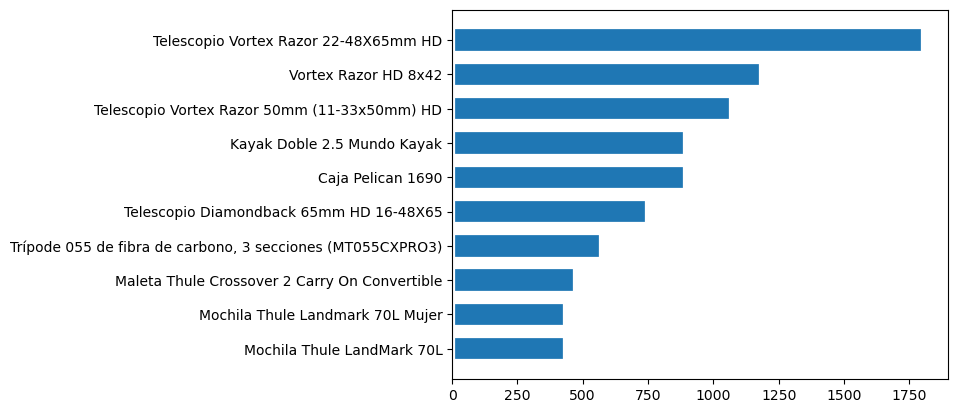

In [87]:
#f) Muestre con un gráfico los 10 productos menos económicos. # Es decir los más caros
top_nombre = pd.DataFrame()
top_precio = pd.DataFrame()
tablaProductos = tablaProductos.sort_values(by='precioOriginal',ascending=False)
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.barh(tablaProductos.iloc[0:10]['Nombre'],tablaProductos.iloc[0:10]['precioOriginal'],edgecolor = "white", linewidth = 4.5)
ax.invert_yaxis()
plt.show()

In [773]:
#g) Aplique a la variable con el estado del producto código disyuntivo completo.
# No se aplica ya que todos los artículos están disponibles, no hay agotados (al menos en lo que se observó). Según segurencia en el foro del profesor Diego, se da permiso de trabajarlo
# de forma constante

                 precioOriginal  PrecioDescuento
precioOriginal         1.000000        -0.102481
PrecioDescuento       -0.102481         1.000000 



<Axes: >

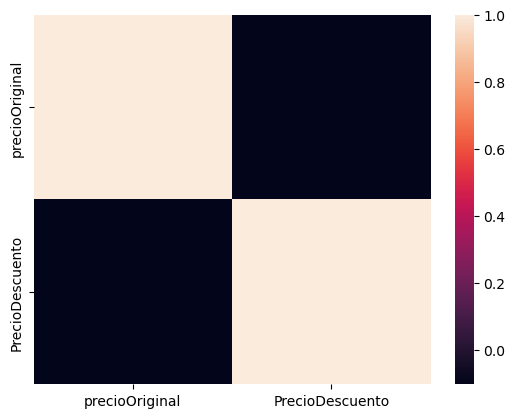

In [61]:
#h) Muestre con un gráfico la matriz de correlaciones. Interprete al menos una correlación.
# Calcula la matriz de correlación
# Análisis: En realidad el ejercicio por las variables que presenta el DataFrame, no tiene mucho de donde tomar para un análisis de correlación 
# sustantivo, ya que la mayoría de las columnas son de tipo object y la del estado se encuentra seteada en que ninguna o prácticamente ninguna
# está agotada. Por lo tanto se tomó la decisión de representar la columna del descuento como numérica (aunque presenta varios 0s) como para poder
# tener un criterio de comparación con respecto a la columna de precioOriginal. En realidad el resultado es el esperado: Una correlación perfecta (1)
# entre ellas mismas (cuando corresponde a la misma) y un valor negativo (correlación fuertemente negativa) entre precioOriginal y PrecioDescuento
# indicando así que cuando una cambia no necesariamente cambia la otra, en cuanto a su comportamiento.
import sys

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = tablaProductos.corr()
print(corr_df, "\n")
#plt.matshow(corr_df)
#plt.show()
sns.heatmap(tablaProductos.corr())